## Section 0 — Problem Statement
This the Walmart sales dataset based on different stores. 

1. Which stores are highest-performing and most volatile? 

2. Does holiday season meaningfully impact sales? 

3. What external factors (temperature, fuel, CPI, unemployment) correlate with sales?

4. How does Walmart understand sales performance and make decisions?

## Section 1 — Data Loading & Quality Check

1. Are there missing values?

2. Are there duplicates?

3. Are there impossible values (negative sales, broken dates)?

4. Are all stores and departments consistently represented?

5. Is the time series continuous?

In [29]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
#Load the dataset using pandas
df = pd.read_csv('../data/Walmart_Sales.csv', parse_dates=['Date'])

In [31]:
# get the info , null and types of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


As you can see there are no missing values in this dataset

In [32]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [33]:
#get the missing values in the dataset
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

This is the statistical summary of the dataset

In [34]:
#statistical summary of the dataset
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [35]:
#check the last few rows of the dataset
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667


In [36]:
# check the first few rows of the dataset
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [37]:
#check the columns in the dataset
df.columns 

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [38]:
#check the number of unique values in each column
df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

Based on the given results above, the walmart dataset indicates that;

1. There are no missing values across all columns based on a full null-value scan

2. There are no duplicated values across all columns based on a full duplicate scan 

3. Using pandas to pd.datetime, I converted the Date series to a proper datetime, no broken dates 

4. Yes, all stores are represented so far, there are 45 stores

5. The time series is continuous across all stores, with no missing weekly records within the observed date range


### Project Overview
##### What does each row represent?
Each row represents the weekly sales performance of a single Walmart store, along with contextual economic and environmental factors observed during that same week

#####  Store
 indicates the Walmart store location
 
##### Date
Represents the week-ending date for reported weekly sales

##### Weekly sales
Total sales revenue generated by the store during that week.

##### Holiday Flag
 Indicates whether a major holiday occurred during the sales week, allowing analysis of holiday-driven demand spikes

##### Temperature
Temperature is an external environmental factor that may influence customer behaviour, store traffic, and operational costs
- Affects customer foot traffic

- Influences product demand (cold vs hot items)

- Impacts energy costs (heating/cooling)

##### Fuel_price 
Fuel price reflects regional transportation and logistics costs, which can indirectly affect customer traffic and distribution expenses.
Fuel price represents regional fuel costs, not store energy bills.
It affects:
- Customer transportation costs

- Supply chain and logistics

- Willingness to travel to stores

##### CPI
CPI reflects inflationary pressure, which influences consumer purchasing power and pricing behaviour.

##### Unemployment
The unemployment rate indicates local economic conditions and consumer spending capacity, which can significantly influence retail sales performance.


# Section 2 — Feature Engineering

In [39]:
df['Store'].value_counts()

Store
1     143
24    143
26    143
27    143
28    143
29    143
30    143
31    143
32    143
33    143
34    143
35    143
36    143
37    143
38    143
39    143
40    143
41    143
42    143
43    143
44    143
25    143
23    143
2     143
22    143
3     143
4     143
5     143
6     143
7     143
8     143
9     143
10    143
11    143
12    143
13    143
14    143
15    143
16    143
17    143
18    143
19    143
20    143
21    143
45    143
Name: count, dtype: int64

In [40]:
print(df.columns.tolist())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [43]:
df['Weekly_Sales'].value_counts()

Weekly_Sales
1643690.90    1
446751.45     1
1332261.01    1
1366193.35    1
1384870.51    1
             ..
551799.63     1
573498.64     1
553901.97     1
533161.64     1
760281.43     1
Name: count, Length: 6435, dtype: int64

# Section 3 — Exploratory Data Analysis (EDA)
### What could Walmart executives care about here?
Walmart executives would care about understanding which stores generate the highest revenue, how sales fluctuate during holiday periods, and how external economic factors such as fuel prices, inflation, and unemployment impact customer demand.

The data can support decisions related to inventory planning, promotional timing, cost management, and identifying stores that require intervention or strategic investment

In [ ]:
#Total weekly sales per store
total_sales_per_store = df.groupby(['Store'])['Weekly_Sales_x'].sum().reset_index()
total_sales_per_store = total_sales_per_store.sort_values(by='Weekly_Sales_x', ascending=False)
total_sales_per_store

,Store,Weekly_Sales_x
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


In [ ]:
#Average weekly sales per store
average_store_sales = df.groupby('Store')['Weekly_Sales_x'].mean().reset_index()
average_store_sales= average_store_sales.sort_values(by='Weekly_Sales_x', ascending=False)
average_store_sales

,Store,Weekly_Sales_x
19,20,2.107677e+06
3,4,2.094713e+06
13,14,2.020978e+06
12,13,2.003620e+06
1,2,1.925751e+06
9,10,1.899425e+06
26,27,1.775216e+06
5,6,1.564728e+06
0,1,1.555264e+06
38,39,1.450668e+06


In [ ]:
# total sales per week 
sales_per_week = df.groupby('Date')['Weekly_Sales_x'].sum().reset_index()
sales_per_week = sales_per_week.sort_values(by='Date', ascending=False)
sales_per_week

,Date,Weekly_Sales_x
142,2012-10-26,45544116.29
141,2012-10-19,45122410.57
140,2012-10-12,46128514.25
139,2012-10-05,47566639.31
138,2012-09-28,43734899.40
...,...,...
4,2010-03-05,46871470.30
3,2010-02-26,43968571.13
2,2010-02-19,48276993.78
1,2010-02-12,48336677.63


In [ ]:
df[df['Date'] == '26-10-2012'][['Weekly_Sales_x', 'Store']].sort_values(by='Weekly_Sales_x', ascending=False)

,Weekly_Sales_x,Store
571,2149594.46,4
1858,2035189.66,13
2859,2031650.55,20
285,1834458.35,2
1429,1744349.05,10
2001,1704357.62,14
3860,1703047.74,27
5576,1569502.00,39
142,1493659.74,1
857,1431426.34,6


In [ ]:
weekly_sales = df.groupby('Date')['Weekly_Sales_x'].sum().reset_index()
weekly_sales = weekly_sales.set_index('Date')

In [ ]:
# Run this AFTER df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

weekly_sales = df.groupby('Date')['Weekly_Sales_x'].sum().reset_index()
weekly_sales = weekly_sales.set_index('Date')

In [ ]:
weekly_sales 

,Weekly_Sales_x
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30
...,...
2012-09-28,43734899.40
2012-10-05,47566639.31
2012-10-12,46128514.25


In [ ]:
df = df.merge(weekly_sales, on='Date')

In [ ]:
df.head()

,Store,Date,Weekly_Sales_x_x,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Total_sales_per_week,IsHoliday,Percent_Weekly_Sales,Weekly_Sales_y,Weekly_Sales_x_y
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,49750740.50,0,3.303852,49750740.50,49750740.50
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,48336677.63,1,3.396918,48336677.63,48336677.63
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,48276993.78,0,3.338999,48276993.78,48276993.78
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,43968571.13,0,3.206217,43968571.13,43968571.13
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,46871470.30,0,3.317171,46871470.30,46871470.30


In [ ]:
print(df.columns.tolist())

['Store', 'Date', 'Weekly_Sales_x_x', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Total_sales_per_week', 'IsHoliday', 'Percent_Weekly_Sales', 'Weekly_Sales_y', 'Weekly_Sales_x_y']


In [ ]:
df['Percent_Weekly_Sales'] = (df['Weekly_Sales_y']/df['Total_sales_per_week']) * 100

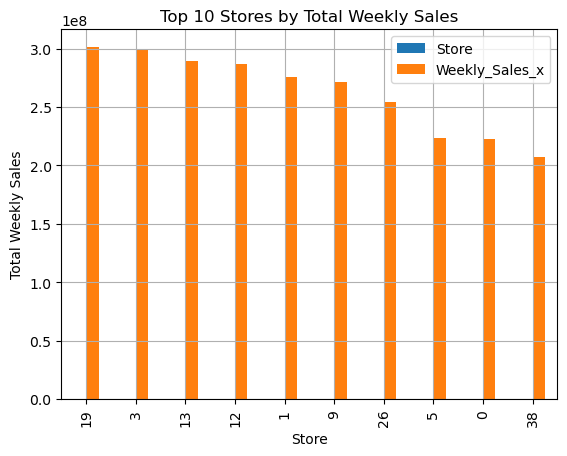

In [ ]:
total_sales_per_store.head(10).plot(kind='bar')
plt.title('Top 10 Stores by Total Weekly Sales')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.show()

 Top 10 Stores by Total Weekly Sales

1. Revenue is concentrated in a small number of stores

2. These stores are critical to Walmart’s overall performance

3. Performance differences between top and bottom of the top 10 are still meaningful

Business implication:

Focus retention, inventory, and operational excellence on these stores

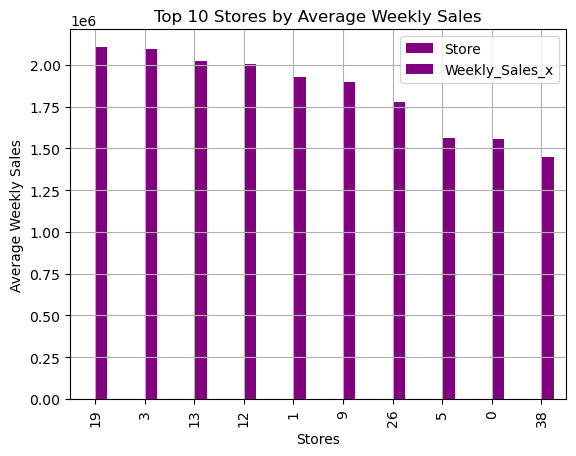

In [ ]:
# Average weekly sales per store plot
average_store_sales.head(10).plot(kind='bar', color='purple')
plt.title('Top 10 Stores by Average Weekly Sales')
plt.xlabel('Stores')
plt.ylabel('Average Weekly Sales')
plt.grid(True)
plt.show()

Top 10 Stores by Average Weekly Sales

1. The same stores dominate average performance

2. Indicates reliable weekly demand

3. Low volatility implied (to be confirmed later with variance)

Business implication:

These stores are predictable and suitable for long-term planning

In this dataset, stores with the highest total sales also exhibit the highest average weekly sales, suggesting consistent performance rather than reliance on seasonal spikes

In [ ]:
print(df['Date'].dtype)   # should say: datetime64[ns]
print(df['Date'].head())  # should show: 2010-02-05, 2010-02-12...

datetime64[ns]
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


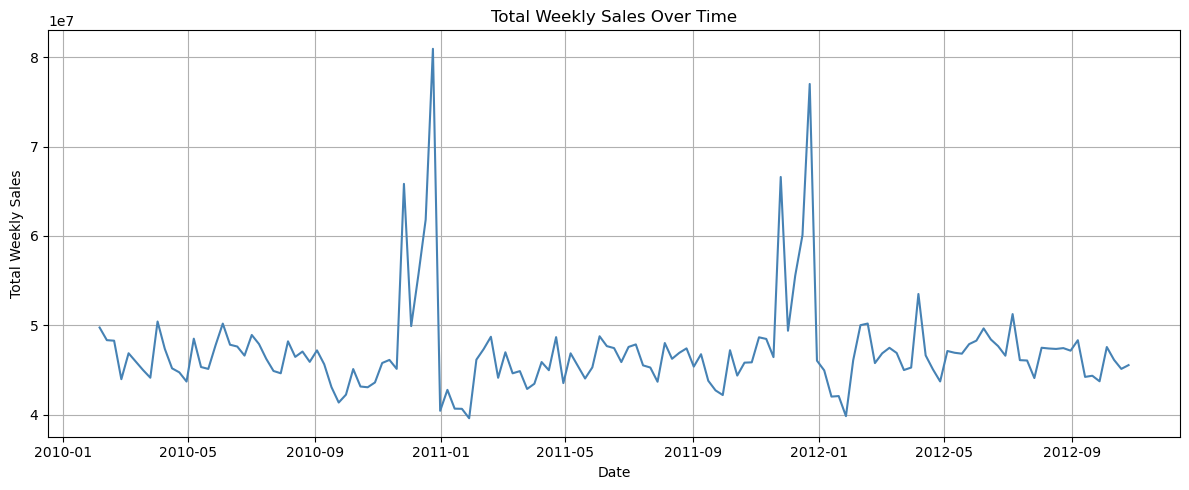

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(weekly_sales.index, weekly_sales['Weekly_Sales_x'], color='steelblue')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

The Purpose of the linechart above is to know wether WALMART is growing or shrinking 
#### QUESTIONS

1. Do I see spikes?

2. Are they align with holidays?

3. Is the trend stable or volatile?

#### ANSWERS

1. Yes, there are spikes 

2. Yes,  they align with the holiday period

3. Weekly sales remain stable for most of the year, with significant but short-lived spikes during event periods, likely driven by holiday demand

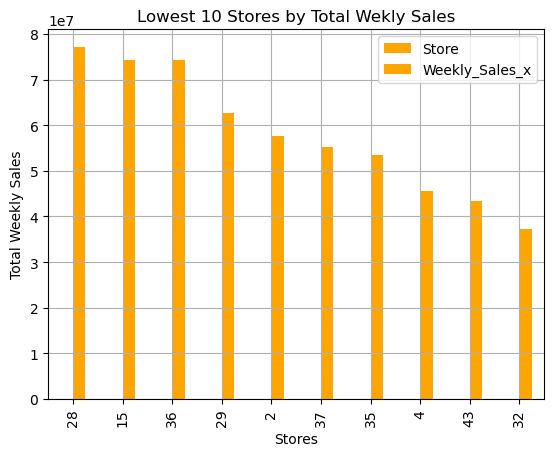

In [ ]:
# 10 Stores with the Lowest weekly sales
total_sales_per_store.tail(10).plot(kind='bar', color='orange')
plt.title('Lowest 10 Stores by Total Wekly Sales')
plt.xlabel('Stores')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.show()

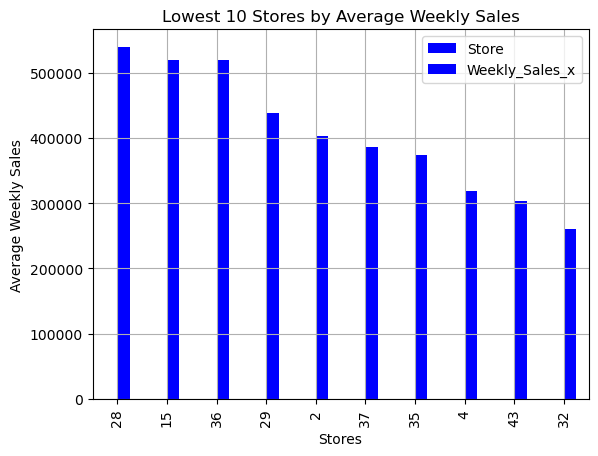

In [ ]:
# 10 Stores with the Lowest average weekly sales
average_store_sales.tail(10).plot(kind='bar', color='blue')
plt.title('Lowest 10 Stores by Average Weekly Sales')
plt.xlabel('Stores')
plt.ylabel('Average Weekly Sales')
plt.grid(True)
plt.show()

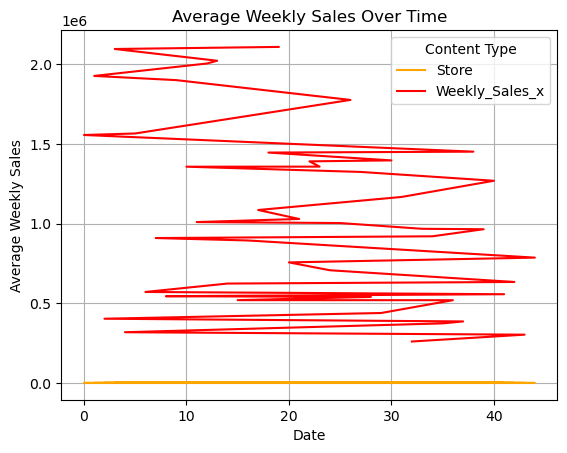

In [ ]:
average_store_sales.plot(kind='line', color=['orange', 'red'])
plt.title('Average Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')
plt.grid(True)
plt.legend(title='Content Type')
plt.show()

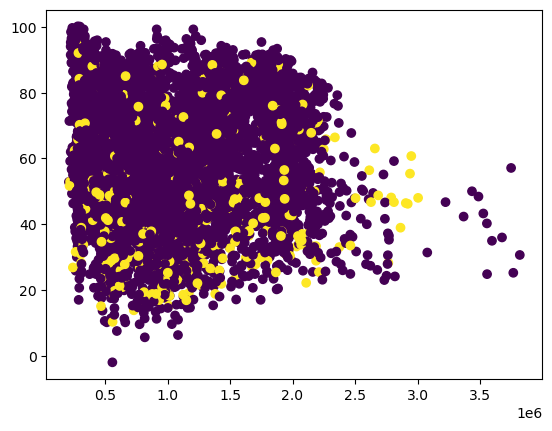

In [ ]:
plt.scatter(data=df, x='Weekly_Sales', y='Temperature', c='Holiday_Flag');
 

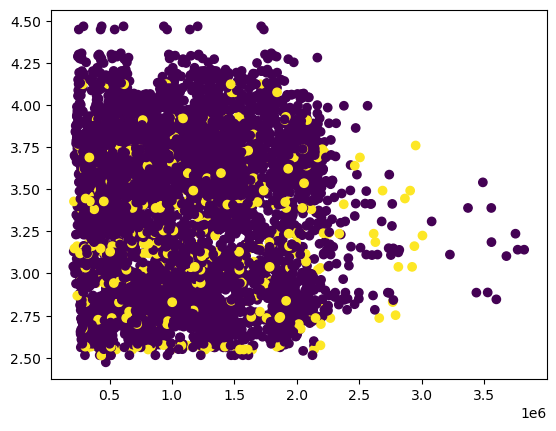

In [ ]:
plt.scatter(data=df, x='Weekly_Sales', y='Fuel_Price', c='Holiday_Flag', cmap='viridis'); 

In [42]:
weekly_sales_volatility = (
    df.groupby('Store')['Weekly_Sales']
      .std()
      .reset_index()
      .sort_values(by='Weekly_Sales', ascending=False)
)

weekly_sales_volatility

,Store,Weekly_Sales
13,14,317569.949476
9,10,302262.062504
19,20,275900.562742
3,4,266201.442297
12,13,265506.995776
22,23,249788.038068
26,27,239930.135688
1,2,237683.694682
38,39,217466.454833
5,6,212525.855862


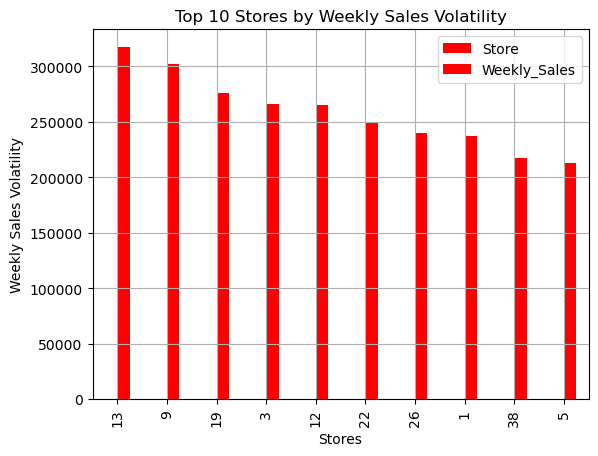

In [ ]:
weekly_sales_volatility.head(10).plot(kind='bar', color='red')
plt.title('Top 10 Stores by Weekly Sales Volatility')
plt.xlabel('Stores')
plt.ylabel('Weekly Sales Volatility')   
plt.grid(True)
plt.show()

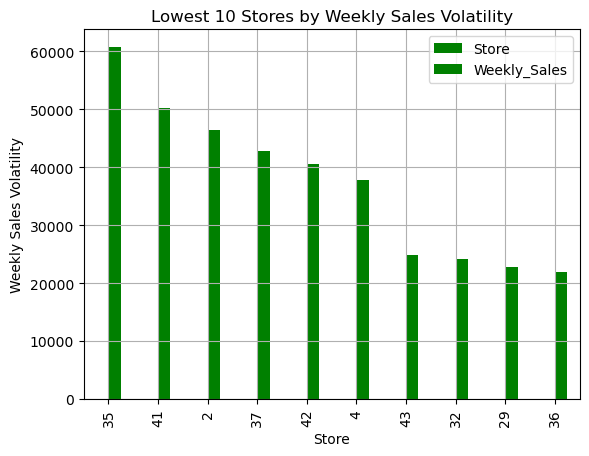

In [ ]:
# Lowest 10 stores with sales volatility
weekly_sales_volatility.tail(10).plot(kind='bar', color='green')
plt.title('Lowest 10 Stores by Weekly Sales Volatility')
plt.xlabel('Store')
plt.ylabel('Weekly Sales Volatility')
plt.grid(True)
plt.show()

In [ ]:
weekly = df.groupby(['Date']).agg(weekly_sales=('Weekly_Sales_y', 'sum'),IsHoliday=('Holiday_Flag', 'max')).reset_index()

In [ ]:
weekly

,Date,weekly_sales,IsHoliday
0,2010-02-05,2.238783e+09,0
1,2010-02-12,2.175150e+09,1
2,2010-02-19,2.172465e+09,0
3,2010-02-26,1.978586e+09,0
4,2010-03-05,2.109216e+09,0
...,...,...,...
138,2012-09-28,1.968070e+09,0
139,2012-10-05,2.140499e+09,0
140,2012-10-12,2.075783e+09,0
141,2012-10-19,2.030508e+09,0


In [ ]:
weekly.describe()

,Date,weekly_sales,IsHoliday
count,143,1.430000e+02,143.000000
mean,2011-06-17 00:00:00,2.120104e+09,0.069930
min,2010-02-05 00:00:00,1.781993e+09,0.000000
25%,2010-10-11 12:00:00,2.019626e+09,0.000000
50%,2011-06-17 00:00:00,2.080975e+09,0.000000
75%,2012-02-20 12:00:00,2.150641e+09,0.000000
max,2012-10-26 00:00:00,3.641914e+09,1.000000
std,NaN,2.449893e+08,0.255926


In [ ]:
weekly.sort_values(by='weekly_sales', ascending=False).head(10)

,Date,weekly_sales,IsHoliday
46,2010-12-24,3.641914e+09,0
98,2011-12-23,3.464921e+09,0
94,2011-11-25,2.996712e+09,1
42,2010-11-26,2.961945e+09,1
45,2010-12-17,2.781936e+09,0
97,2011-12-16,2.703856e+09,0
44,2010-12-10,2.505005e+09,0
96,2011-12-09,2.500252e+09,0
113,2012-04-06,2.407604e+09,0
126,2012-07-06,2.306386e+09,0


December 23 and December 25 caused the spike, so Holiday period

<Axes: xlabel='Date'>

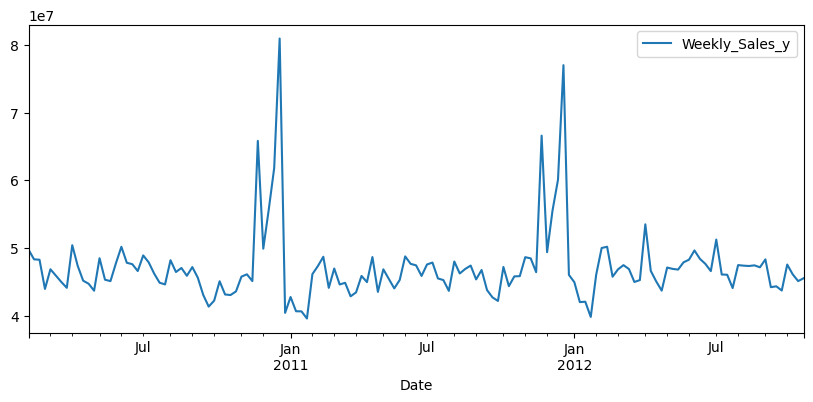

In [ ]:
store_id = 20

df[df['Store'] == store_id].plot(
    x='Date', y='Weekly_Sales_y', figsize=(10,4)
)


In [ ]:
df[(df['Store'] == store_id) &
   (df['Date'].between('2010-11-12','2012-01-06'))]

,Store,Date,Weekly_Sales_x_x,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Total_sales_per_week,IsHoliday,Percent_Weekly_Sales,Weekly_Sales_y,Weekly_Sales_x_y
2757,20,2010-11-12,2187765.28,0,42.38,2.931,205.209861,7.484,46124800.83,0,100.0,46124800.83,46124800.83
2758,20,2010-11-19,2105058.91,0,45.88,3.000,205.099281,7.484,45125584.18,0,100.0,45125584.18,45125584.18
2759,20,2010-11-26,2811634.04,1,46.66,3.039,204.962100,7.484,65821003.24,1,100.0,65821003.24,65821003.24
2760,20,2010-12-03,2416051.17,0,35.47,3.046,204.824919,7.484,49909027.88,0,100.0,49909027.88,49909027.88
2761,20,2010-12-10,2752122.08,0,24.27,3.109,204.687738,7.484,55666770.39,0,100.0,55666770.39,55666770.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2813,20,2011-12-09,2546123.78,0,41.64,3.415,211.866786,7.082,55561147.70,0,100.0,55561147.70,55561147.70
2814,20,2011-12-16,2762816.65,0,37.16,3.413,212.068504,7.082,60085695.94,0,100.0,60085695.94,60085695.94
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082,76998241.31,0,100.0,76998241.31,76998241.31
2816,20,2011-12-30,2043245.00,1,36.35,3.389,212.403576,7.082,46042461.04,1,100.0,46042461.04,46042461.04


In [ ]:
df.groupby('Store')['Weekly_Sales_y'].agg(['mean','median','std'])

,mean,median,std
Store,,,
1,4.711342e+07,46243899.58,5.444206e+06
2,4.711342e+07,46243899.58,5.444206e+06
3,4.711342e+07,46243899.58,5.444206e+06
4,4.711342e+07,46243899.58,5.444206e+06
5,4.711342e+07,46243899.58,5.444206e+06
6,4.711342e+07,46243899.58,5.444206e+06
7,4.711342e+07,46243899.58,5.444206e+06
8,4.711342e+07,46243899.58,5.444206e+06
9,4.711342e+07,46243899.58,5.444206e+06


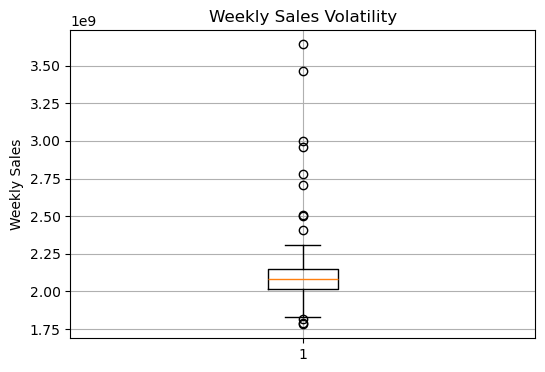

In [ ]:
# Boxplot of  weekly sales
plt.figure(figsize=(6,4))
plt.boxplot(weekly['weekly_sales'])
plt.title("Weekly Sales Volatility")
plt.ylabel("Weekly Sales")
plt.grid(True)  
plt.show()

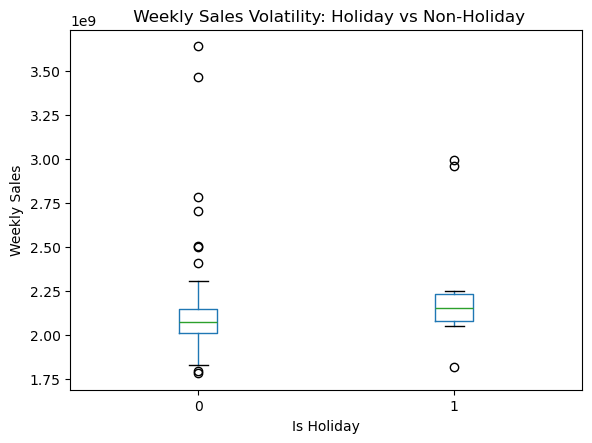

In [ ]:
weekly.boxplot(column='weekly_sales', by='IsHoliday', grid=False)
plt.title(" Weekly Sales Volatility: Holiday vs Non-Holiday")
plt.suptitle("")  # To remove the automatic 'Boxplot grouped by IsHoliday' title
plt.xlabel("Is Holiday")
plt.ylabel("Weekly Sales")
plt.show()

Holiday weeks show higher but more stable sales compared to non-holiday weeks, indicating predictable demand patterns. 

Non-holiday weeks exhibit greater variability and more extreme outliers, suggesting operational risk from promotions, regional events, or anomalies. This volatility should be considered in forecasting and inventory planning

In [ ]:
weekly_sales.describe()

,Date,Total_sales_per_week,IsHoliday
count,143,1.430000e+02,143.000000
mean,2011-06-17 00:00:00,4.711342e+07,0.069930
min,2010-02-05 00:00:00,3.959985e+07,0.000000
25%,2010-10-11 12:00:00,4.488059e+07,0.000000
50%,2011-06-17 00:00:00,4.624390e+07,0.000000
75%,2012-02-20 12:00:00,4.779202e+07,0.000000
max,2012-10-26 00:00:00,8.093142e+07,1.000000
std,NaN,5.444206e+06,0.255926


In [ ]:
# Clean up merge duplicates
df = df.drop(columns=['Weekly_Sales_y'], errors='ignore')
df = df.rename(columns={'Weekly_Sales_x': 'Weekly_Sales'})

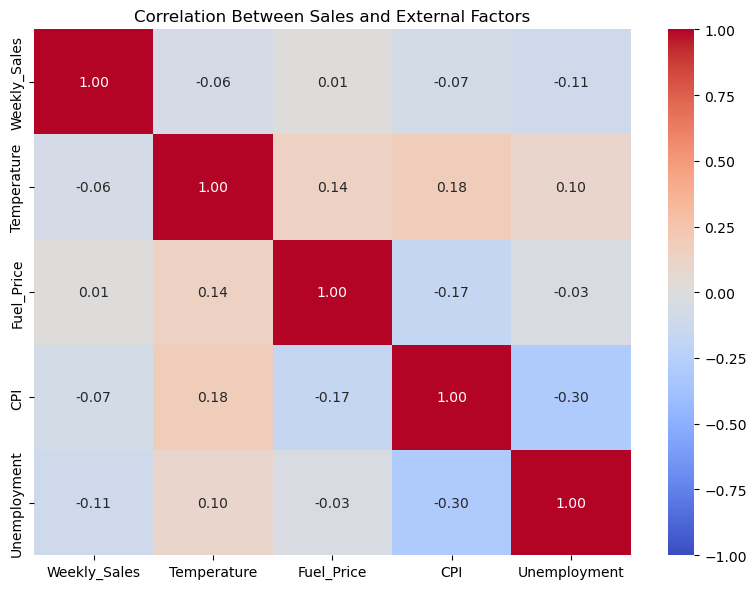

In [ ]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,        # show numbers inside boxes
    cmap='coolwarm',   # red = positive, blue = negative
    fmt='.2f',         # 2 decimal places
    vmin=-1, vmax=1    # fix the scale
)
plt.title('Correlation Between Sales and External Factors')
plt.tight_layout()
plt.show()

- Which factor correlates most with sales?

- Is unemployment negatively correlated? (you'd expect so)

- Does temperature matter at all?

### Key Finding — Correlation Analysis

- None of the external factors (Temperature, Fuel Price, CPI, 
Unemployment) showed strong correlation with Weekly Sales. 

- The strongest relationship was Unemployment at -0.11, suggesting 
that when joblessness rises, spending falls slightly, but the 
effect is weak.

- This implies that sales performance is driven more by store-specific 
factors (location, size, local demographics) than by macroeconomic 
conditions. 
Future analysis should incorporate store type or square 
footage data to explore this further.

- Interestingly, CPI and Unemployment showed a -0.30 correlation, 
the strongest relationship in the dataset consistent with the 
economic principle that high unemployment periods tend to coincide 
with lower inflation.